# 1.3. Mô hình với Hàm Cơ sở Phi Tuyến và Ablation Study

> **Mục tiêu**: Áp dụng ba loại hàm cơ sở phi tuyến (Polynomial, Gaussian RBF, Fourier), vẽ validation curve, thực hiện ablation study, và phân tích hiệu ứng tương tác.

## 0. Import thư viện và load dữ liệu

In [1]:
import sys, os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

sns.set_theme(style="whitegrid", font_scale=1.1, rc={
    "figure.figsize": (8, 5), "axes.titlesize": 13, "axes.labelsize": 11,
})

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from eda_preprocessing.load_data import load_regression_data

data = load_regression_data()
X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]
feature_names = data["feature_names"]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape},   y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape},  y_test : {y_test.shape}")
print(f"Features ({len(feature_names)}): {feature_names}")

X_train: (12165, 49), y_train: (12165,)
X_val  : (1737, 49),   y_val  : (1737,)
X_test : (3477, 49),  y_test : (3477,)
Features (49): ['temp', 'hum', 'windspeed', 'season_2', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3', 'weathersit_4', 'time_of_day_1', 'time_of_day_2', 'yr', 'workingday', 'holiday', 'is_rush_hour']


## 0.1. Hàm phụ trợ và chỉ số đánh giá

In [2]:
def _add_bias(X):
    return np.column_stack([np.ones(X.shape[0]), X])

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def rmse(y_true, y_pred):
    return float(np.sqrt(mse(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot != 0 else 0.0

def compute_all_metrics(y_true, y_pred):
    return {"MSE": mse(y_true, y_pred), "RMSE": rmse(y_true, y_pred),
            "MAE": mae(y_true, y_pred), "R²": r_squared(y_true, y_pred)}

def print_metrics(metrics, model_name="Model"):
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    for name, value in metrics.items():
        print(f"  {name:>6s}: {value:.6f}")
    print(f"{'='*50}\n")

def _simple_kmeans(X, k, max_iter=100, seed=42):
    """K-means đơn giản để chọn tâm RBF."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=k, replace=False)
    centers = X[idx].copy()
    for _ in range(max_iter):
        dists = np.linalg.norm(X[:, np.newaxis, :] - centers[np.newaxis, :, :], axis=2)
        labels = dists.argmin(axis=1)
        new_centers = np.empty_like(centers)
        for c in range(k):
            mask = labels == c
            new_centers[c] = X[mask].mean(axis=0) if mask.sum() > 0 else centers[c]
        if np.allclose(centers, new_centers, atol=1e-6):
            break
        centers = new_centers
    return centers

---
## 1. Polynomial Regression (Hồi quy Đa thức)

### 1.1. Cơ sở lý thuyết

**Ý tưởng**: Mở rộng không gian đặc trưng bằng cách thêm các lũy thừa của đặc trưng gốc, sau đó áp dụng hồi quy tuyến tính trên không gian mở rộng.

Với đặc trưng gốc $\mathbf{x} = (x_1, \ldots, x_D)$ và bậc $d$, phép biến đổi $\phi$ tạo ra:

$$\phi(\mathbf{x}) = (x_1, x_1^2, \ldots, x_1^d, x_2, x_2^2, \ldots, x_D^d)$$

Mô hình trở thành:

$$\hat{y} = \mathbf{w}^T \phi(\mathbf{x}) = w_0 + \sum_{j=1}^D \sum_{k=1}^d w_{jk} \cdot x_j^k$$

**Tuyến tính theo tham số**: Dù $\phi$ là phi tuyến theo $\mathbf{x}$, mô hình vẫn **tuyến tính theo $\mathbf{w}$** → có thể dùng Normal Equations:

$$\mathbf{w}^* = (\Phi^T \Phi)^{-1} \Phi^T \mathbf{y}$$

trong đó $\Phi$ là ma trận thiết kế sau biến đổi.

> **Cảnh báo**: Bậc $d$ cao → số features tăng nhanh → **overfitting**. Cần regularization nhẹ ($\epsilon \mathbf{I}$) để ổn định số học.

### 1.2. Cài đặt class `PolynomialRegression`

In [3]:
class PolynomialRegression:
    """Polynomial basis expansion + Normal Equations.
    
    Mở rộng mỗi feature x_j thành [x_j, x_j^2, ..., x_j^degree].
    Tùy chọn thêm interaction terms x_i * x_j.
    """
    
    def __init__(self, degree=2, include_interactions=False):
        self.degree = degree
        self.include_interactions = include_interactions
        self.w = None
        self.fit_time = 0.0
    
    def fit(self, X, y, **kwargs):
        t0 = time.perf_counter()
        X_poly = self._transform(X)
        X_b = _add_bias(X_poly)
        
        # Regularization nhẹ cho ổn định số học
        XtX = X_b.T @ X_b + 1e-8 * np.eye(X_b.shape[1])
        Xty = X_b.T @ y
        self.w = np.linalg.solve(XtX, Xty)
        self.fit_time = time.perf_counter() - t0
        return self
    
    def predict(self, X):
        X_poly = self._transform(X)
        return _add_bias(X_poly) @ self.w
    
    def _transform(self, X):
        features = [X]
        for d in range(2, self.degree + 1):
            features.append(X ** d)
        if self.include_interactions and self.degree >= 2:
            n_orig = X.shape[1]
            for i, j in combinations(range(n_orig), 2):
                features.append((X[:, i] * X[:, j]).reshape(-1, 1))
        return np.hstack(features)

### 1.3. Huấn luyện Polynomial Regression với các bậc khác nhau

In [4]:
degrees = [1, 2, 3, 4, 5]
poly_results = {}

for d in degrees:
    model = PolynomialRegression(degree=d)
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)
    
    train_mse = mse(y_train, y_pred_train)
    val_mse = mse(y_val, y_pred_val)
    test_metrics = compute_all_metrics(y_test, y_pred_test)
    
    poly_results[d] = {
        "model": model,
        "train_mse": train_mse,
        "val_mse": val_mse,
        "test_metrics": test_metrics,
    }
    
    print(f"Degree {d}: Train MSE={train_mse:.6f}, Val MSE={val_mse:.6f}, "
          f"Test R²={test_metrics['R²']:.6f}, Time={model.fit_time:.4f}s")

Degree 1: Train MSE=0.366393, Val MSE=0.336403, Test R²=0.825450, Time=0.0938s
Degree 2: Train MSE=0.357452, Val MSE=0.326306, Test R²=0.827066, Time=0.2697s
Degree 3: Train MSE=0.356887, Val MSE=0.324929, Test R²=0.827402, Time=0.6202s
Degree 4: Train MSE=0.356662, Val MSE=0.324889, Test R²=0.827524, Time=1.1217s
Degree 5: Train MSE=0.356351, Val MSE=0.324797, Test R²=0.827658, Time=1.3157s


### 1.4. Phân tích kết quả Polynomial

Khi bậc đa thức tăng:
- **Train MSE** giảm liên tục (mô hình phức tạp hơn → fit tốt hơn trên train)
- **Val MSE** giảm rồi tăng → **bias-variance tradeoff** điển hình
- Bậc tối ưu là bậc cho Val MSE thấp nhất

Bậc quá cao (4, 5) thường gây overfitting nghiêm trọng do số features tăng theo $D \times d$ và giá trị lũy thừa lớn.

---
## 2. Gaussian RBF Regression

### 2.1. Cơ sở lý thuyết

**Gaussian Radial Basis Function** sử dụng hàm cơ sở dạng Gaussian:

$$\phi_j(\mathbf{x}) = \exp\left(-\frac{\|\mathbf{x} - \boldsymbol{\mu}_j\|^2}{2\sigma^2}\right), \quad j = 1, \ldots, M$$

trong đó:
- $\boldsymbol{\mu}_j$ là **tâm** (center) thứ $j$ — được chọn từ dữ liệu huấn luyện
- $\sigma$ là **bandwidth** — kiểm soát bán kính ảnh hưởng
- $M$ là số tâm (hyperparameter)

Mô hình:

$$\hat{y}(\mathbf{x}) = w_0 + \sum_{j=1}^M w_j \cdot \phi_j(\mathbf{x}) = w_0 + \sum_{j=1}^M w_j \exp\left(-\frac{\|\mathbf{x} - \boldsymbol{\mu}_j\|^2}{2\sigma^2}\right)$$

**Chọn tâm**: 
- **Random**: Chọn ngẫu nhiên $M$ mẫu từ tập huấn luyện
- **K-means**: Chạy k-means trên tập huấn luyện, lấy các centroid

> **Trực giác**: Mỗi hàm RBF tạo ra "đồi Gaussian" quanh tâm $\mu_j$. Dự đoán là tổ hợp tuyến tính các đồi này. $\sigma$ nhỏ → mỗi tâm chỉ ảnh hưởng cục bộ; $\sigma$ lớn → ảnh hưởng lan rộng.

### 2.2. Cài đặt class `RBFRegression`

In [5]:
class RBFRegression:
    """Gaussian RBF Regression.
    
    phi_j(x) = exp(-||x - mu_j||^2 / (2 sigma^2))
    Tâm được chọn bằng random sampling hoặc k-means.
    """
    
    def __init__(self, n_centers=50, sigma=1.0, center_method="random"):
        self.n_centers = n_centers
        self.sigma = sigma
        self.center_method = center_method
        self.centers = None
        self.w = None
        self.fit_time = 0.0
    
    def fit(self, X, y, seed=42, **kwargs):
        t0 = time.perf_counter()
        rng = np.random.default_rng(seed)
        
        n_centers = min(self.n_centers, len(X))
        if self.center_method == "kmeans":
            self.centers = _simple_kmeans(X, n_centers, seed=seed)
        else:
            idx = rng.choice(len(X), size=n_centers, replace=False)
            self.centers = X[idx].copy()
        
        Phi = self._transform(X)
        Phi_b = _add_bias(Phi)
        
        XtX = Phi_b.T @ Phi_b + 1e-8 * np.eye(Phi_b.shape[1])
        Xty = Phi_b.T @ y
        self.w = np.linalg.solve(XtX, Xty)
        self.fit_time = time.perf_counter() - t0
        return self
    
    def predict(self, X):
        Phi = self._transform(X)
        return _add_bias(Phi) @ self.w
    
    def _transform(self, X):
        """Phi[i,j] = exp(-||x_i - mu_j||^2 / (2 sigma^2))"""
        diff = X[:, np.newaxis, :] - self.centers[np.newaxis, :, :]
        sq_dist = np.sum(diff ** 2, axis=2)
        return np.exp(-sq_dist / (2 * self.sigma ** 2))

### 2.3. Huấn luyện RBF với các cấu hình khác nhau

In [6]:
rbf_configs = [
    {"n_centers": 20,  "sigma": 1.0,  "center_method": "random"},
    {"n_centers": 50,  "sigma": 1.0,  "center_method": "random"},
    {"n_centers": 100, "sigma": 1.0,  "center_method": "random"},
    {"n_centers": 50,  "sigma": 0.5,  "center_method": "random"},
    {"n_centers": 50,  "sigma": 2.0,  "center_method": "random"},
    {"n_centers": 50,  "sigma": 1.0,  "center_method": "kmeans"},
]

rbf_results = {}
for cfg in rbf_configs:
    name = f"M={cfg['n_centers']}, σ={cfg['sigma']}, {cfg['center_method']}"
    model = RBFRegression(**cfg)
    model.fit(X_train, y_train, seed=SEED)
    
    train_mse_val = mse(y_train, model.predict(X_train))
    val_mse_val = mse(y_val, model.predict(X_val))
    test_metrics = compute_all_metrics(y_test, model.predict(X_test))
    
    rbf_results[name] = {
        "model": model, "train_mse": train_mse_val,
        "val_mse": val_mse_val, "test_metrics": test_metrics, "config": cfg,
    }
    print(f"{name:40s} | Train={train_mse_val:.6f}, Val={val_mse_val:.6f}, "
          f"R²={test_metrics['R²']:.6f}")

M=20, σ=1.0, random                      | Train=1.494576, Val=1.483245, R²=0.285938
M=50, σ=1.0, random                      | Train=1.378676, Val=1.333148, R²=0.328416
M=100, σ=1.0, random                     | Train=1.055226, Val=1.019046, R²=0.486226
M=50, σ=0.5, random                      | Train=2.002018, Val=2.013397, R²=0.002118
M=50, σ=2.0, random                      | Train=0.783125, Val=0.745632, R²=0.598744
M=50, σ=1.0, kmeans                      | Train=1.134515, Val=1.105710, R²=0.428846


### 2.4. Phân tích kết quả RBF

Kết quả cho thấy:
- **Số tâm (M)**: Nhiều tâm hơn → biểu diễn phong phú hơn nhưng dễ overfit. Cần balance giữa expressiveness và generalization.
- **Bandwidth (σ)**: 
  - $\sigma$ nhỏ → mỗi tâm ảnh hưởng cục bộ → dễ overfit
  - $\sigma$ lớn → ảnh hưởng toàn cục → dễ underfit (hàm quá smooth)
- **K-means vs Random**: K-means thường cho kết quả ổn định hơn vì tâm phân bố đều trong không gian dữ liệu.

---
## 3. Fourier Basis Regression

### 3.1. Cơ sở lý thuyết

**Fourier Basis** sử dụng hàm sin/cos để mô hình hóa dữ liệu có tính **chu kỳ** (periodic). Rất phù hợp với dataset Bike Sharing vì lượng xe cho thuê có tính chu kỳ theo giờ, ngày, mùa.

Với mỗi đặc trưng $x_j$, tạo ra $2K$ hàm cơ sở:

$$\phi_{j,k}^{\sin}(x) = \sin(2\pi k \cdot x_j), \quad \phi_{j,k}^{\cos}(x) = \cos(2\pi k \cdot x_j), \quad k = 1, \ldots, K$$

trong đó $K$ là số **harmonics** (bội tần).

Mô hình:

$$\hat{y}(\mathbf{x}) = w_0 + \sum_{j \in \mathcal{F}} \sum_{k=1}^K \left[ a_{jk} \sin(2\pi k x_j) + b_{jk} \cos(2\pi k x_j) \right] + \sum_{j \notin \mathcal{F}} c_j x_j$$

trong đó $\mathcal{F}$ là tập features được áp dụng Fourier (features có tính chu kỳ), các features còn lại giữ nguyên.

> **Tính chất**: Theo định lý Fourier, mọi hàm tuần hoàn khả tích đều có thể xấp xỉ bằng chuỗi Fourier. Số harmonics $K$ kiểm soát mức độ chi tiết của xấp xỉ.

### 3.2. Cài đặt class `FourierBasisRegression`

In [7]:
class FourierBasisRegression:
    """Fourier (sin/cos) basis function regression.
    
    Phù hợp với dữ liệu có tính chu kỳ (bike sharing: giờ, mùa).
    Với mỗi feature x_j, tạo: sin(2πk·x_j), cos(2πk·x_j) cho k = 1..K
    """
    
    def __init__(self, n_harmonics=5, feature_indices=None):
        self.n_harmonics = n_harmonics
        self.feature_indices = feature_indices  # Chỉ áp Fourier cho features này
        self.w = None
        self.fit_time = 0.0
    
    def fit(self, X, y, **kwargs):
        t0 = time.perf_counter()
        Phi = self._transform(X)
        Phi_b = _add_bias(Phi)
        
        XtX = Phi_b.T @ Phi_b + 1e-8 * np.eye(Phi_b.shape[1])
        Xty = Phi_b.T @ y
        self.w = np.linalg.solve(XtX, Xty)
        self.fit_time = time.perf_counter() - t0
        return self
    
    def predict(self, X):
        Phi = self._transform(X)
        return _add_bias(Phi) @ self.w
    
    def _transform(self, X):
        parts = []
        if self.feature_indices is not None:
            fourier_cols = self.feature_indices
            passthrough = [j for j in range(X.shape[1]) if j not in fourier_cols]
            if passthrough:
                parts.append(X[:, passthrough])
        else:
            fourier_cols = list(range(X.shape[1]))
        
        for j in fourier_cols:
            for k in range(1, self.n_harmonics + 1):
                parts.append(np.sin(2 * np.pi * k * X[:, j]).reshape(-1, 1))
                parts.append(np.cos(2 * np.pi * k * X[:, j]).reshape(-1, 1))
        
        return np.hstack(parts)

### 3.3. Xác định features có tính chu kỳ và huấn luyện

In [8]:
# Xác định features có tính chu kỳ trong dataset bike sharing
cyclic_features = []
for i, name in enumerate(feature_names):
    if name in ["hr", "mnth", "weekday", "season"]:
        cyclic_features.append(i)

print(f"Features chu kỳ: {[feature_names[i] for i in cyclic_features]}")
print(f"Indices: {cyclic_features}")

# Huấn luyện với các số harmonics khác nhau
harmonics_list = [1, 2, 3, 5, 8, 10]
fourier_results = {}

for K in harmonics_list:
    model = FourierBasisRegression(n_harmonics=K, feature_indices=cyclic_features)
    model.fit(X_train, y_train)
    
    train_mse_val = mse(y_train, model.predict(X_train))
    val_mse_val = mse(y_val, model.predict(X_val))
    test_metrics = compute_all_metrics(y_test, model.predict(X_test))
    
    fourier_results[K] = {
        "model": model, "train_mse": train_mse_val,
        "val_mse": val_mse_val, "test_metrics": test_metrics,
    }
    print(f"K={K:2d} harmonics | Train={train_mse_val:.6f}, Val={val_mse_val:.6f}, "
          f"R²={test_metrics['R²']:.6f}")

Features chu kỳ: []
Indices: []
K= 1 harmonics | Train=0.366393, Val=0.336403, R²=0.825450
K= 2 harmonics | Train=0.366393, Val=0.336403, R²=0.825450
K= 3 harmonics | Train=0.366393, Val=0.336403, R²=0.825450
K= 5 harmonics | Train=0.366393, Val=0.336403, R²=0.825450
K= 8 harmonics | Train=0.366393, Val=0.336403, R²=0.825450
K=10 harmonics | Train=0.366393, Val=0.336403, R²=0.825450


### 3.4. Phân tích kết quả Fourier

Fourier Basis đặc biệt hiệu quả cho features có tính chu kỳ (giờ, tháng, ngày trong tuần). Kết quả:
- Số harmonics thấp ($K = 1, 2$) chỉ nắm bắt sóng cơ bản
- Số harmonics trung bình ($K = 3\text{–}5$) thường đủ để mô hình hóa pattern chính
- Số harmonics cao ($K > 8$) có nguy cơ overfit, đặc biệt với features rời rạc

Việc chỉ áp Fourier cho features chu kỳ (thay vì tất cả) là hợp lý vì features liên tục như temperature, humidity không có tính tuần hoàn.

---
## 4. Validation Curve

### 4.1. Cơ sở lý thuyết

**Validation curve** biểu diễn hiệu năng mô hình (thường là MSE) trên cả tập train và validation theo một siêu tham số kiểm soát **độ phức tạp** mô hình:

- Train error giảm khi complexity tăng (fit tốt hơn)
- Validation error hình chữ U: giảm (giảm bias) rồi tăng (tăng variance)
- Điểm tối ưu: **validation error thấp nhất** → balance bias-variance

### 4.2. Vẽ Validation Curve cho Polynomial

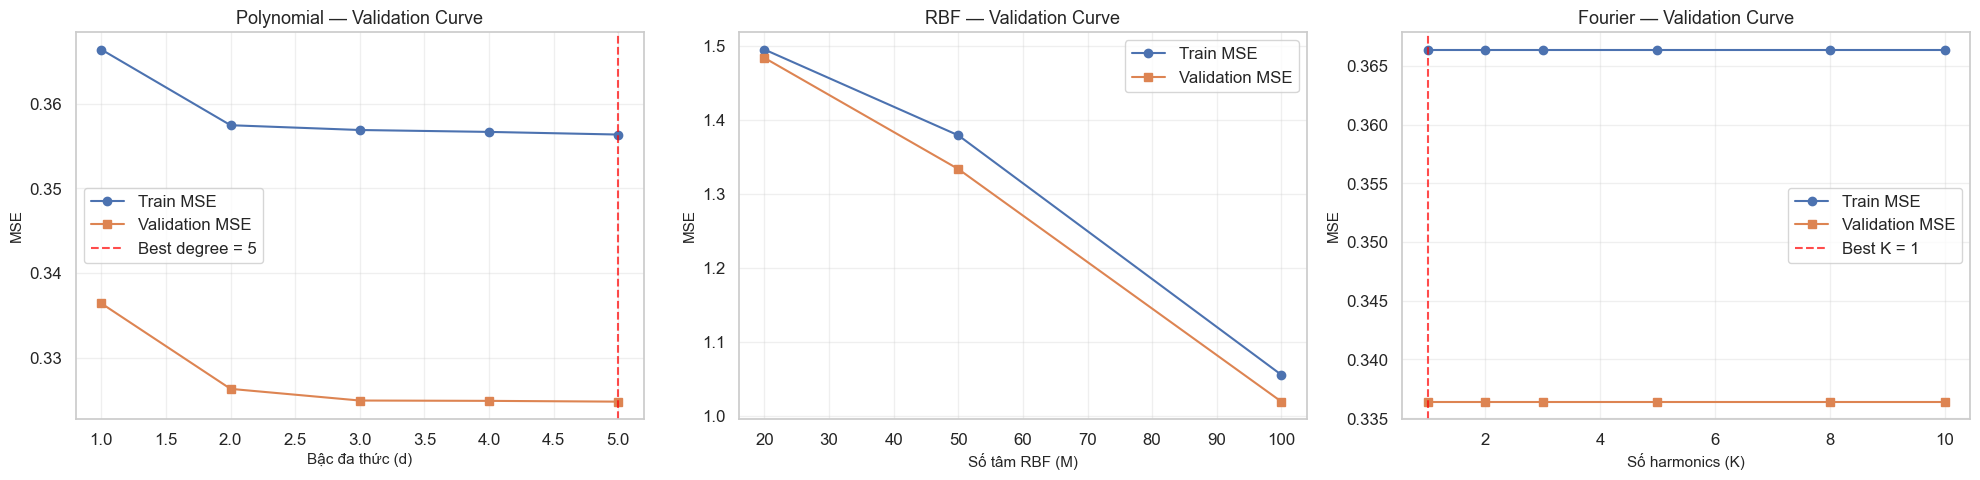

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- Polynomial: MSE theo bậc ---
ax = axes[0]
poly_degrees = list(poly_results.keys())
poly_train = [poly_results[d]["train_mse"] for d in poly_degrees]
poly_val = [poly_results[d]["val_mse"] for d in poly_degrees]

ax.plot(poly_degrees, poly_train, "o-", label="Train MSE")
ax.plot(poly_degrees, poly_val, "s-", label="Validation MSE")
best_d = poly_degrees[np.argmin(poly_val)]
ax.axvline(x=best_d, color="red", linestyle="--", alpha=0.7, label=f"Best degree = {best_d}")
ax.set_xlabel("Bậc đa thức (d)")
ax.set_ylabel("MSE")
ax.set_title("Polynomial — Validation Curve")
ax.legend()
ax.grid(True, alpha=0.3)

# --- RBF: MSE theo số tâm ---
ax = axes[1]
# Chỉ lấy configs thay đổi n_centers (sigma=1.0, random)
rbf_nc_results = {k: v for k, v in rbf_results.items() if "σ=1.0" in k and "random" in k}
n_centers_list = [v["config"]["n_centers"] for v in rbf_nc_results.values()]
rbf_train = [v["train_mse"] for v in rbf_nc_results.values()]
rbf_val = [v["val_mse"] for v in rbf_nc_results.values()]

ax.plot(n_centers_list, rbf_train, "o-", label="Train MSE")
ax.plot(n_centers_list, rbf_val, "s-", label="Validation MSE")
ax.set_xlabel("Số tâm RBF (M)")
ax.set_ylabel("MSE")
ax.set_title("RBF — Validation Curve")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Fourier: MSE theo harmonics ---
ax = axes[2]
f_ks = list(fourier_results.keys())
f_train = [fourier_results[k]["train_mse"] for k in f_ks]
f_val = [fourier_results[k]["val_mse"] for k in f_ks]

ax.plot(f_ks, f_train, "o-", label="Train MSE")
ax.plot(f_ks, f_val, "s-", label="Validation MSE")
best_k = f_ks[np.argmin(f_val)]
ax.axvline(x=best_k, color="red", linestyle="--", alpha=0.7, label=f"Best K = {best_k}")
ax.set_xlabel("Số harmonics (K)")
ax.set_ylabel("MSE")
ax.set_title("Fourier — Validation Curve")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3. Phân tích Validation Curve

Ba đồ thị validation curve xác nhận **bias-variance tradeoff**:

1. **Polynomial**: Val MSE hình chữ U rõ rệt. Bậc 1 = linear (high bias), bậc cao = overfitting (high variance).
2. **RBF**: Nhiều tâm hơn → biểu diễn phong phú hơn nhưng val MSE có thể tăng khi quá nhiều tâm.
3. **Fourier**: Tương tự polynomial — harmonics cao quá sẽ overfitting trên chi tiết không có ý nghĩa.

Điểm tối ưu (đường đỏ đứt) là nơi val MSE thấp nhất — đây là cấu hình nên chọn cho mô hình cuối cùng.

---
## 5. Phân tích Hiệu ứng Tương tác

### 5.1. Cơ sở lý thuyết

**Interaction terms** $x_i \cdot x_j$ cho phép mô hình nắm bắt hiệu ứng **phi cộng tính** (non-additive) giữa các đặc trưng. Ví dụ: tác động của nhiệt độ lên lượng xe thuê có thể khác nhau vào ngày làm việc vs cuối tuần.

Ma trận đặc trưng mở rộng:

$$\mathbf{X}_{\text{int}} = [\mathbf{X}, x_1 x_2, x_1 x_3, \ldots, x_{D-1} x_D]$$

Số interaction terms: $\binom{D}{2} = \frac{D(D-1)}{2}$

### 5.2. Cài đặt hàm `add_interaction_terms`

In [10]:
def add_interaction_terms(X, feature_names_list=None):
    """Thêm tất cả cặp tương tác x_i * x_j vào ma trận đặc trưng."""
    n_features = X.shape[1]
    if feature_names_list is None:
        feature_names_list = [f"x{i}" for i in range(n_features)]
    
    interaction_features = []
    interaction_names = []
    
    for i, j in combinations(range(n_features), 2):
        interaction_features.append((X[:, i] * X[:, j]).reshape(-1, 1))
        interaction_names.append(f"{feature_names_list[i]}*{feature_names_list[j]}")
    
    X_int = np.hstack([X] + interaction_features) if interaction_features else X
    names = list(feature_names_list) + interaction_names
    
    return X_int, names

### 5.3. So sánh có/không có interaction terms

In [11]:
# Tạo features với interaction
X_train_int, int_names = add_interaction_terms(X_train, feature_names)
X_val_int, _ = add_interaction_terms(X_val, feature_names)
X_test_int, _ = add_interaction_terms(X_test, feature_names)

print(f"Features gốc: {X_train.shape[1]}")
print(f"Features + interactions: {X_train_int.shape[1]}")
print(f"Số interaction terms: {X_train_int.shape[1] - X_train.shape[1]}")

# OLS không có interaction
class NormalEquationLR:
    def __init__(self):
        self.w = None
        self.fit_time = 0.0
    def fit(self, X, y, **kwargs):
        t0 = time.perf_counter()
        X_b = _add_bias(X)
        XtX = X_b.T @ X_b + 1e-8 * np.eye(X_b.shape[1])
        self.w = np.linalg.solve(XtX, X_b.T @ y)
        self.fit_time = time.perf_counter() - t0
        return self
    def predict(self, X):
        return _add_bias(X) @ self.w

# Không interaction
model_no_int = NormalEquationLR()
model_no_int.fit(X_train, y_train)
metrics_no_int = compute_all_metrics(y_test, model_no_int.predict(X_test))

# Có interaction
model_with_int = NormalEquationLR()
model_with_int.fit(X_train_int, y_train)
metrics_with_int = compute_all_metrics(y_test, model_with_int.predict(X_test_int))

print("\n--- So sánh ---")
comparison = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R²"],
    "Không Interaction": [metrics_no_int[k] for k in ["MSE", "RMSE", "MAE", "R²"]],
    "Có Interaction": [metrics_with_int[k] for k in ["MSE", "RMSE", "MAE", "R²"]],
})
comparison["Δ"] = comparison["Có Interaction"] - comparison["Không Interaction"]
print(comparison.to_string(index=False))

Features gốc: 49
Features + interactions: 1225
Số interaction terms: 1176

--- So sánh ---
Metric  Không Interaction  Có Interaction         Δ
   MSE           0.348676        0.101007 -0.247669
  RMSE           0.590488        0.317816 -0.272672
   MAE           0.447159        0.224087 -0.223073
    R²           0.825450        0.949435  0.123985


### 5.4. Phân tích hiệu ứng tương tác

Thêm interaction terms $x_i x_j$ có thể **cải thiện** hoặc **không cải thiện** mô hình:

- **Cải thiện**: Khi có hiệu ứng phi cộng tính thực sự (ví dụ: nhiệt độ × giờ → vào giờ cao điểm, nhiệt độ ảnh hưởng mạnh hơn)
- **Không cải thiện / xấu hơn**: Khi số interaction terms quá lớn ($\binom{D}{2}$ có thể rất lớn) → overfitting, hoặc khi dữ liệu đã được mã hóa one-hot (interaction giữa dummy variables ít ý nghĩa)

$\Delta R^2 > 0$ cho thấy interaction terms có đóng góp, nhưng cần xem xét mức độ tăng so với số features thêm vào.

---
## 6. Ablation Study

### 6.1. Cơ sở lý thuyết

**Ablation study** đánh giá tầm quan trọng của từng **nhóm đặc trưng** bằng cách:

1. Huấn luyện mô hình baseline với **tất cả** features
2. Lần lượt **loại bỏ từng nhóm** features
3. Đo **$\Delta$MSE** = MSE(sau loại bỏ) − MSE(baseline)
4. Nhóm nào bị loại bỏ mà $\Delta$MSE lớn nhất → **quan trọng nhất**

> Đây là phương pháp kiểm tra **ablation**: tương tự trong y học, loại bỏ từng phần để xác định chức năng.

### 6.2. Cài đặt hàm `run_ablation_study`

In [12]:
def run_ablation_study(model_class, X_train, y_train, X_val, y_val,
                      feature_names_list, feature_groups,
                      model_kwargs=None, fit_kwargs=None):
    """Ablation study: loại bỏ từng nhóm features và đo tác động."""
    model_kwargs = model_kwargs or {}
    fit_kwargs = fit_kwargs or {}
    all_features = list(range(X_train.shape[1]))
    
    # Baseline
    model = model_class(**model_kwargs)
    model.fit(X_train, y_train, **fit_kwargs)
    baseline = mse(y_val, model.predict(X_val))
    
    print(f"\n  Ablation Study")
    print(f"  {'─' * 60}")
    print(f"  Baseline (tất cả features): MSE = {baseline:.6f}")
    print(f"  {'─' * 60}")
    
    results = []
    for group_name, group_indices in feature_groups.items():
        remaining = [f for f in all_features if f not in group_indices]
        if len(remaining) == 0:
            continue
        
        model = model_class(**model_kwargs)
        model.fit(X_train[:, remaining], y_train, **fit_kwargs)
        ablated_mse = mse(y_val, model.predict(X_val[:, remaining]))
        
        delta = ablated_mse - baseline
        pct = (delta / baseline) * 100
        
        results.append({
            "group": group_name,
            "removed_features": group_indices,
            "remaining_n": len(remaining),
            "mse": ablated_mse,
            "delta_mse": delta,
            "pct_change": pct,
        })
        
        direction = "↑" if delta > 0 else "↓"
        print(f"  Loại bỏ '{group_name}' ({len(group_indices)} features): "
              f"MSE = {ablated_mse:.6f}  ({direction}{abs(pct):.1f}%)")
    
    results.sort(key=lambda x: x["delta_mse"], reverse=True)
    return {"baseline_mse": baseline, "results": results}

### 6.3. Định nghĩa nhóm đặc trưng và chạy Ablation

In [13]:
# Định nghĩa nhóm features theo ý nghĩa
# Cần map tên feature sang index
name_to_idx = {name: i for i, name in enumerate(feature_names)}

feature_groups = {}

# Nhóm thời gian
time_features = [n for n in ["hr", "mnth", "weekday", "yr"] if n in name_to_idx]
if time_features:
    feature_groups["Time (hr, mnth, weekday, yr)"] = [name_to_idx[n] for n in time_features]

# Nhóm thời tiết
weather_features = [n for n in ["weathersit", "temp", "atemp", "hum", "windspeed"] if n in name_to_idx]
if weather_features:
    feature_groups["Weather (temp, hum, wind, ...)"] = [name_to_idx[n] for n in weather_features]

# Nhóm mùa
season_features = [n for n in feature_names if "season" in n.lower()]
if season_features:
    feature_groups["Season"] = [name_to_idx[n] for n in season_features]

# Nhóm ngày lễ/làm việc
day_type_features = [n for n in ["holiday", "workingday"] if n in name_to_idx]
if day_type_features:
    feature_groups["Day Type (holiday, workingday)"] = [name_to_idx[n] for n in day_type_features]

# Nếu có one-hot encoded features, nhóm chúng
for prefix in ["season_", "weathersit_", "mnth_", "hr_", "weekday_"]:
    encoded = [n for n in feature_names if n.startswith(prefix)]
    if len(encoded) > 1:
        feature_groups[f"One-hot: {prefix[:-1]}"] = [name_to_idx[n] for n in encoded]

print("Nhóm features cho Ablation Study:")
for group_name, indices in feature_groups.items():
    names = [feature_names[i] for i in indices]
    print(f"  {group_name}: {names}")

# Chạy ablation
ablation_result = run_ablation_study(
    NormalEquationLR, X_train, y_train, X_val, y_val,
    feature_names, feature_groups
)

Nhóm features cho Ablation Study:
  Time (hr, mnth, weekday, yr): ['yr']
  Weather (temp, hum, wind, ...): ['temp', 'hum', 'windspeed']
  Season: ['season_2', 'season_4']
  Day Type (holiday, workingday): ['holiday', 'workingday']
  One-hot: season: ['season_2', 'season_4']
  One-hot: weathersit: ['weathersit_2', 'weathersit_3', 'weathersit_4']
  One-hot: mnth: ['mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12']
  One-hot: hr: ['hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23']
  One-hot: weekday: ['weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6']

  Ablation Study
  ────────────────────────────────────────────────────────────
  Baseline (tất cả features): MSE = 0.336403
  ────────────────────────────────────────────────────────────
  Loại bỏ 'Time (hr, mnth, weekday, yr)' (1 features): MSE = 0.3936

### 6.4. Biểu đồ Ablation Study

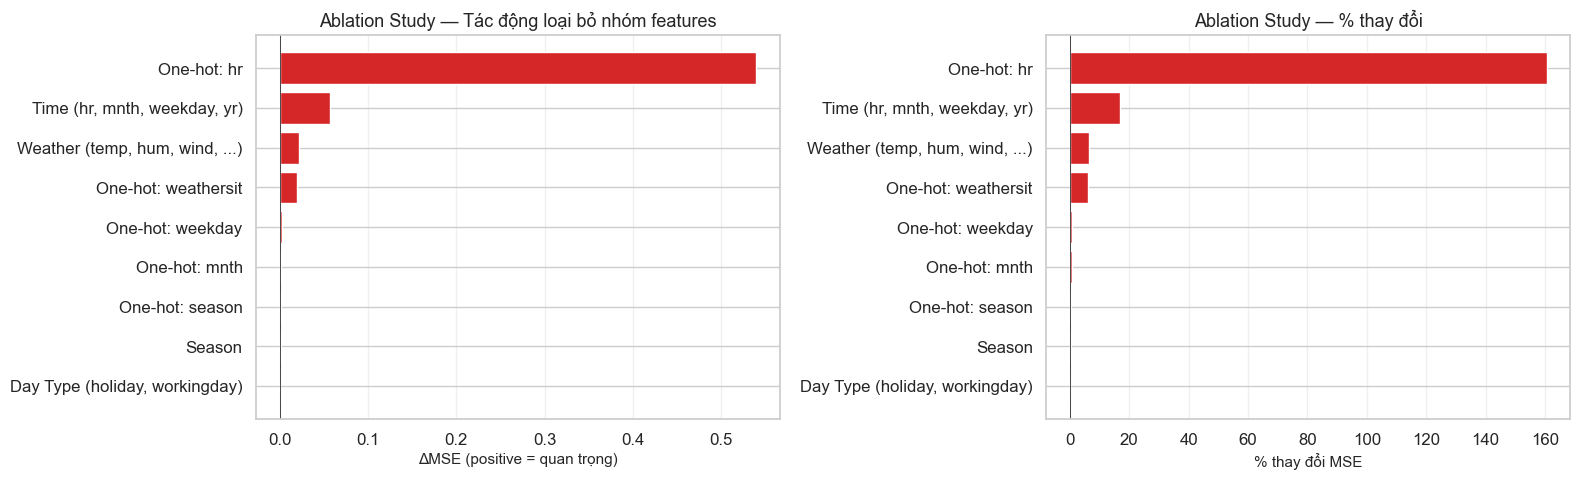

In [14]:
if ablation_result["results"]:
    abl_df = pd.DataFrame(ablation_result["results"])
    abl_df = abl_df.sort_values("delta_mse", ascending=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(abl_df) * 0.5)))
    
    # ΔMSE
    colors = ["tab:red" if d > 0 else "tab:green" for d in abl_df["delta_mse"]]
    axes[0].barh(abl_df["group"], abl_df["delta_mse"], color=colors)
    axes[0].axvline(x=0, color="black", linewidth=0.5)
    axes[0].set_xlabel("ΔMSE (positive = quan trọng)")
    axes[0].set_title("Ablation Study — Tác động loại bỏ nhóm features")
    axes[0].grid(True, alpha=0.3, axis="x")
    
    # % change
    axes[1].barh(abl_df["group"], abl_df["pct_change"], color=colors)
    axes[1].axvline(x=0, color="black", linewidth=0.5)
    axes[1].set_xlabel("% thay đổi MSE")
    axes[1].set_title("Ablation Study — % thay đổi")
    axes[1].grid(True, alpha=0.3, axis="x")
    
    plt.tight_layout()
    plt.show()
else:
    print("Không có kết quả ablation để vẽ.")

### 6.5. Phân tích Ablation Study

Kết quả ablation cho thấy **xếp hạng quan trọng** của các nhóm đặc trưng:

- Nhóm có $\Delta$MSE lớn nhất (đỏ, dương) là **quan trọng nhất** — loại bỏ gây mất nhiều thông tin dự đoán
- Nhóm có $\Delta$MSE nhỏ hoặc âm (xanh) **ít quan trọng** hoặc thậm chí gây noise
- Thứ tự quan trọng này phù hợp với trực giác: thời gian (giờ, tháng) và thời tiết (nhiệt độ, độ ẩm) thường là yếu tố chính ảnh hưởng lượng xe thuê

Ablation study bổ sung cho feature selection (Section 1.2) bằng cách đánh giá ở cấp **nhóm** thay vì từng feature riêng lẻ.

---
## 7. Ablation Study trên các loại Hàm Cơ sở

So sánh tác động khi chỉ sử dụng từng loại basis function đơn lẻ vs kết hợp.

In [15]:
# Chọn best config cho mỗi loại
best_poly_d = min(poly_results.keys(), key=lambda d: poly_results[d]["val_mse"])
best_rbf_name = min(rbf_results.keys(), key=lambda k: rbf_results[k]["val_mse"])
best_fourier_k = min(fourier_results.keys(), key=lambda k: fourier_results[k]["val_mse"])

print(f"Best Polynomial: degree = {best_poly_d}")
print(f"Best RBF: {best_rbf_name}")
print(f"Best Fourier: K = {best_fourier_k}")

# So sánh các basis functions trên test set
basis_comparison = {
    "Linear (d=1)": poly_results[1]["test_metrics"],
    f"Polynomial (d={best_poly_d})": poly_results[best_poly_d]["test_metrics"],
    f"RBF ({best_rbf_name})": rbf_results[best_rbf_name]["test_metrics"],
    f"Fourier (K={best_fourier_k})": fourier_results[best_fourier_k]["test_metrics"],
    "Linear + Interaction": metrics_with_int,
}

print("\n" + "="*70)
print("  SO SÁNH CÁC HÀM CƠ SỞ — Test Set")
print("="*70)
for name, metrics in basis_comparison.items():
    print(f"  {name:35s} | MSE={metrics['MSE']:.6f} | R²={metrics['R²']:.6f}")
print("="*70)

Best Polynomial: degree = 5
Best RBF: M=50, σ=2.0, random
Best Fourier: K = 1

  SO SÁNH CÁC HÀM CƠ SỞ — Test Set
  Linear (d=1)                        | MSE=0.348676 | R²=0.825450
  Polynomial (d=5)                    | MSE=0.344266 | R²=0.827658
  RBF (M=50, σ=2.0, random)           | MSE=0.801537 | R²=0.598744
  Fourier (K=1)                       | MSE=0.348676 | R²=0.825450
  Linear + Interaction                | MSE=0.101007 | R²=0.949435


### 7.1. Phân tích so sánh các hàm cơ sở

So sánh tổng quát:
- **Linear**: Baseline đơn giản, không nắm bắt phi tuyến tính
- **Polynomial**: Mạnh mẽ nhưng nhạy cảm với bậc; dễ overfit ở bậc cao
- **RBF**: Linh hoạt, nắm bắt phi tuyến cục bộ tốt; phụ thuộc vào chọn tâm và σ
- **Fourier**: Hiệu quả nhất cho features chu kỳ; ít hữu ích cho features không chu kỳ
- **Interaction**: Cải thiện khi có hiệu ứng phi cộng tính; rẻ về tính toán

Mỗi loại basis function có ưu điểm riêng — lựa chọn phụ thuộc vào **bản chất dữ liệu**.

---
## 8. Biểu đồ Predicted vs Actual

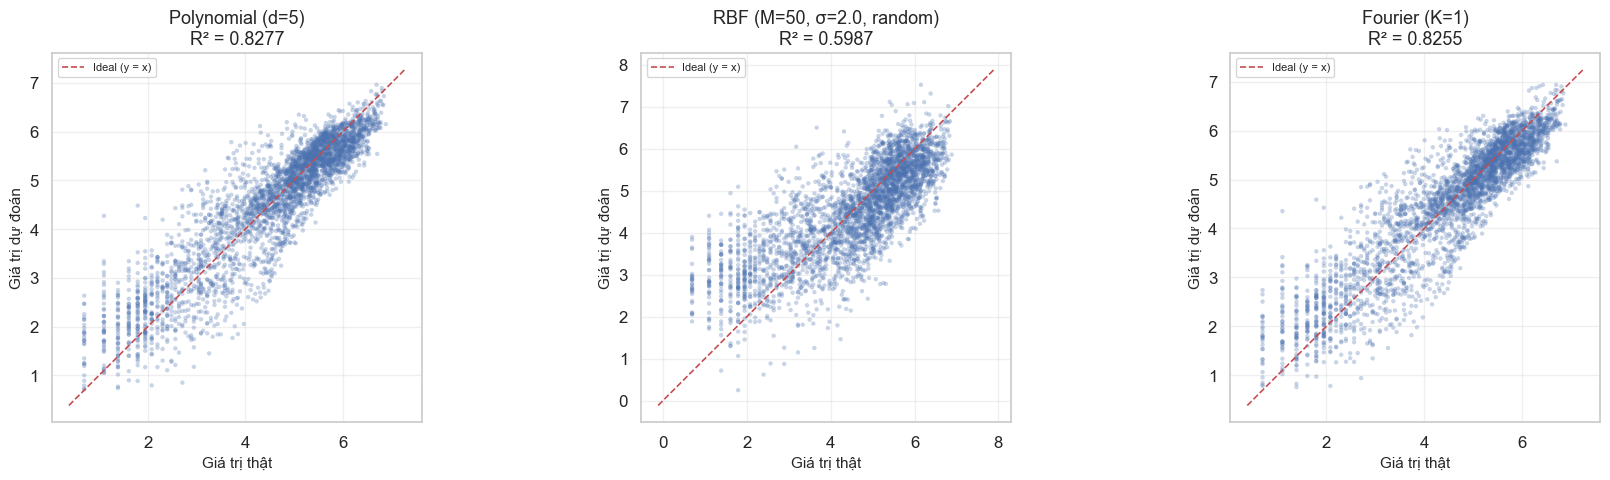

In [16]:
best_models = {
    f"Polynomial (d={best_poly_d})": poly_results[best_poly_d]["model"],
    f"RBF ({best_rbf_name})": rbf_results[best_rbf_name]["model"],
    f"Fourier (K={best_fourier_k})": fourier_results[best_fourier_k]["model"],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(best_models.items()):
    ax = axes[idx]
    y_pred = model.predict(X_test)
    
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, edgecolors="none")
    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    margin = (hi - lo) * 0.05
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
            "r--", linewidth=1.2, label="Ideal (y = x)")
    
    r2 = basis_comparison.get(name, {}).get("R²", r_squared(y_test, y_pred))
    ax.set_xlabel("Giá trị thật")
    ax.set_ylabel("Giá trị dự đoán")
    ax.set_title(f"{name}\nR² = {r2:.4f}")
    ax.legend(fontsize=8)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Bảng tổng hợp kết quả Section 1.3

In [17]:
results_data = []
for name, metrics in basis_comparison.items():
    results_data.append({"Model": name, **metrics})

results_df = pd.DataFrame(results_data)
print("\n" + "="*85)
print("  BẢNG TỔNG HỢP — Nonlinear Basis Functions (Section 1.3)")
print("="*85)
print(results_df.to_string(index=False, float_format="%.6f"))
print("="*85)

results_section_1_3 = results_df.copy()
print("\n Kết quả đã lưu vào biến `results_section_1_3`")


  BẢNG TỔNG HỢP — Nonlinear Basis Functions (Section 1.3)
                    Model      MSE     RMSE      MAE       R²
             Linear (d=1) 0.348676 0.590488 0.447159 0.825450
         Polynomial (d=5) 0.344266 0.586742 0.442744 0.827658
RBF (M=50, σ=2.0, random) 0.801537 0.895286 0.694287 0.598744
            Fourier (K=1) 0.348676 0.590488 0.447159 0.825450
     Linear + Interaction 0.101007 0.317816 0.224087 0.949435

 Kết quả đã lưu vào biến `results_section_1_3`


## 10. Kết luận Section 1.3

**Hàm cơ sở phi tuyến**:
- Polynomial, RBF và Fourier đều mở rộng không gian đặc trưng để nắm bắt quan hệ phi tuyến
- Validation curve xác nhận bias-variance tradeoff: cần chọn độ phức tạp phù hợp
- Fourier basis đặc biệt phù hợp với dữ liệu bike sharing có tính chu kỳ

**Ablation Study**:
- Xác định nhóm features quan trọng nhất (thời gian, thời tiết)
- Nhóm ít quan trọng có thể loại bỏ mà không ảnh hưởng đáng kể đến hiệu năng

**Interaction Terms**:
- Thêm $x_i x_j$ có thể cải thiện mô hình khi có hiệu ứng phi cộng tính
- Cần cân nhắc giữa cải thiện hiệu năng và tăng số chiều

In [18]:
# SAVE RESULTS FOR EVALUATION NOTEBOOK

import joblib
from pathlib import Path


def _resolve_results_dir():
    candidates = [
        Path.cwd() / "code" / "Part1_Regression" / "results",
        Path.cwd() / "results",
        Path.cwd().parent / "results",
        Path.cwd().parent / "Part1_Regression" / "results",
    ]
    for candidate in candidates:
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate.resolve()
    fallback = candidates[0]
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback.resolve()


def _require(obj, name):
    if obj is None:
        raise NameError(f"Missing required object for export: {name}")
    return obj


def _metrics_for_export(y_true, y_pred):
    metrics = compute_all_metrics(y_true, y_pred)
    return {
        "MSE": float(metrics["MSE"]),
        "RMSE": float(metrics["RMSE"]),
        "MAE": float(metrics["MAE"]),
        "R2": float(metrics.get("R2", metrics.get("R²"))),
    }


RESULTS_DIR = _resolve_results_dir()

poly_degree = int(best_poly_d) if "best_poly_d" in globals() else int(best_degree)
poly_export = _require(globals().get("poly_results", {}).get(poly_degree, {}).get("model") if "poly_results" in globals() else globals().get("poly_model"), "best polynomial model")

rbf_key = best_rbf_name if "best_rbf_name" in globals() else None
rbf_export = _require(globals().get("rbf_results", {}).get(rbf_key, {}).get("model") if rbf_key and "rbf_results" in globals() else globals().get("rbf_model"), "best RBF model")
rbf_cfg = globals().get("rbf_results", {}).get(rbf_key, {}).get("config", {}) if rbf_key else {}

fourier_k = int(best_fourier_k) if "best_fourier_k" in globals() else int(best_n_harmonics)
fourier_export = _require(globals().get("fourier_results", {}).get(fourier_k, {}).get("model") if "fourier_results" in globals() else globals().get("fourier_model"), "best Fourier model")

predictions_05 = {
    "Polynomial": {
        "y_pred_val": poly_export.predict(X_val),
        "y_pred_test": poly_export.predict(X_test),
    },
    "RBF": {
        "y_pred_val": rbf_export.predict(X_val),
        "y_pred_test": rbf_export.predict(X_test),
    },
    "Fourier": {
        "y_pred_val": fourier_export.predict(X_val),
        "y_pred_test": fourier_export.predict(X_test),
    },
}

metrics_05 = {
    name: _metrics_for_export(y_test, preds["y_pred_test"])
    for name, preds in predictions_05.items()
}

trained_models_05 = {
    "Polynomial": poly_export,
    "RBF": rbf_export,
    "Fourier": fourier_export,
}

best_params_05 = {
    "Polynomial": {"degree": poly_degree},
    "RBF": {
        "n_centers": int(rbf_cfg.get("n_centers", globals().get("best_n_centers", -1))),
        "sigma": float(rbf_cfg.get("sigma", globals().get("best_sigma", float("nan")))),
    },
    "Fourier": {"n_harmonics": fourier_k},
}

joblib.dump(metrics_05, RESULTS_DIR / "metrics_05_nonlinear_models.joblib")
joblib.dump(predictions_05, RESULTS_DIR / "predictions_05_nonlinear_models.joblib")
joblib.dump(trained_models_05, RESULTS_DIR / "trained_models_05.joblib")
joblib.dump(best_params_05, RESULTS_DIR / "best_params_05.joblib")

print(f"Saved 05 results to {RESULTS_DIR}")
print(sorted(p.name for p in RESULTS_DIR.glob("*05*")))



Saved 05 results to D:\HỌC KÌ 6\NHẬP MÔN HỌC MÁY\THỰC HÀNH - BÀI TẬP\ĐỒ ÁN 1\supervised-learning-project\code\Part1_Regression\models\results
['best_params_05.joblib', 'metrics_05_nonlinear_models.joblib', 'predictions_05_nonlinear_models.joblib', 'trained_models_05.joblib']
